In [15]:
import sys
import numpy
import pandas
import sklearn

print(sys.version.split()[0], numpy.__version__, pandas.__version__, sklearn.__version__)

3.13.9 2.0.2 2.3.3 1.6.1


In [16]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

SEED = 2633

data = pd.read_csv("data/heart_disease.csv")

feature_names = [c for c in data.columns if c != "disease"]

X = data[feature_names].to_numpy()
y = data["disease"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=SEED
)

print(data.shape, round(y.mean(), 3), X_train.shape, X_test.shape)

(297, 14) 0.461 (207, 13) (90, 13)


 Part 1 — Entropy and Information Gain

1. Parent Entropy

We have 12 patients:
- 6 patients have disease = 1
- 6 patients have disease = 0

P(1) = 6/12 = 0.5
P(0) = 6/12 = 0.5

H = -0.5 * log2(0.5) - 0.5 * log2(0.5)

H = 1

The entropy is 1 because both classes have the same number of patients.

 2. Information Gain — age_55_plus

For age_55_plus = 1:
- 6 patients: 5 with disease and 1 without disease.
- H1 = -(5/6) × log2(5/6) - (1/6) × log2(1/6)
- H1 = 0.6500

For age_55_plus = 0:
- 6 patients: 1 with disease and 5 without disease.
- H0 = -(1/6) × log2(1/6) - (5/6) × log2(5/6)
- H0 = 0.6500

Weighted entropy:

H(children) = (6/12) × 0.6500 + (6/12) × 0.6500 = 0.6500

Information Gain:

IG = 1 - 0.6500 = **0.3500**

The age feature reduces the entropy, so it is useful for splitting the patients.

 Information Gain — exercise_angina

For exercise_angina = 1:
- 4 patients: 4 with disease, 0 without disease.
- H1 = 0

For exercise_angina = 0:
- 8 patients: 2 with disease, 6 without disease.
- H0 = -(2/8) * log2(2/8) - (6/8) * log2(6/8)
- H0 = 0.8113

Weighted entropy:

H(children) = (4/12) * 0 + (8/12) * 0.8113
H(children) = 0.5409

Information Gain:

IG = 1 - 0.5409 = 0.4591

The information gain is higher than for age_55_plus.
This feature gives a better split.

 Information Gain — male

For male = 1:
- 6 patients: 3 with disease, 3 without disease.
- H1 = -(3/6) * log2(3/6) - (3/6) * log2(3/6) = 1

For male = 0:
- 6 patients: 3 with disease, 3 without disease.
- H0 = 1

Weighted entropy:
H(children) = (6/12) * 1 + (6/12) * 1 = 1

IG(male) = 1 - 1 = 0

 Information Gain — high_bp

For high_bp = 1:
- 6 patients: 4 with disease, 2 without disease.
- H1 = -(4/6) * log2(4/6) - (2/6) * log2(2/6) = 0.9183

For high_bp = 0:
- 6 patients: 2 with disease, 4 without disease.
- H0 = 0.9183

Weighted entropy:
H(children) = (6/12) * 0.9183 + (6/12) * 0.9183 = 0.9183

IG(high_bp) = 1 - 0.9183 = 0.0817

 Root Selection

The information gains are:

- age_55_plus = 0.3500
- exercise_angina = 0.4591
- male = 0.0000
- high_bp = 0.0817

I choose exercise_angina as the root because it has the highest information gain.

 Question 3 — One Level Down

After the root split, exercise_angina = 1 is pure.

For exercise_angina = 0, we have 8 patients:
- 2 with disease
- 6 without disease

Parent entropy = 0.8113

**age_55_plus:**

IG = 0.8113 - [(2/8) * 1 + (6/8) * 0.6500]

IG = 0.0738

**male:**

IG = 0.8113 - [(3/8) * 0 + (5/8) * 0.9710]

IG = 0.2044

**high_bp:**

IG = 0.8113 - [(3/8) * 0.9183 + (5/8) * 0.7219]

IG = 0.0157

**Conclusion:**

I choose male because it has the highest information gain in this branch.

At the root, male had zero information gain. But after the first split, the data changed. Now male can separate patients better than the other features.

Part 2 — Decision Tree from Scratch

In [17]:
def entropy(y):
    """Calculate entropy of class labels."""
    counts = np.bincount(y)
    probabilities = counts[counts > 0] / len(y)
    return -np.sum(probabilities * np.log2(probabilities))

In [18]:
print(entropy(np.array([1, 1, 0, 0])))
print(entropy(np.array([1, 1, 1, 1])))
print(entropy(np.array([1, 1, 1, 0])))

1.0
-0.0
0.8112781244591328


In [19]:
def information_gain(y, left):
    """Calculate information gain after splitting."""
    y_left = y[left]
    y_right = y[~left]

    n = len(y)

    weighted_entropy = (
        len(y_left) / n * entropy(y_left)
        + len(y_right) / n * entropy(y_right)
    )

    return entropy(y) - weighted_entropy

In [20]:
y = np.array([1, 1, 0, 0])
left = np.array([True, True, False, False])

print(information_gain(y, left))

1.0


In [21]:
def best_split(X, y, min_samples_leaf=1):
    """Find the feature and threshold with the highest gain."""
    best_gain = 0
    best_result = None

    for feature in range(X.shape[1]):
        values = np.unique(X[:, feature])
        thresholds = (values[:-1] + values[1:]) / 2

        for threshold in thresholds:
            left = X[:, feature] <= threshold

            if left.sum() < min_samples_leaf:
                continue

            if (~left).sum() < min_samples_leaf:
                continue

            gain = information_gain(y, left)

            if gain > best_gain + 1e-12:
                best_gain = gain
                best_result = (feature, threshold, gain)

    return best_result

In [22]:
X_example = np.array([[25], [30], [50], [60]])
y_example = np.array([0, 0, 1, 1])

print(best_split(X_example, y_example))

(0, np.float64(40.0), np.float64(1.0))


In [23]:
from sklearn.tree import DecisionTreeClassifier

our_split = best_split(X_train, y_train)

ref = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=1,
    random_state=SEED
)

ref.fit(X_train, y_train)

print("Our split:", feature_names[our_split[0]], our_split[1])
print("Sklearn split:", feature_names[ref.tree_.feature[0]], ref.tree_.threshold[0])

Our split: thal 4.5
Sklearn split: thal 4.5


In [24]:
def build_tree(X, y, max_depth=None, min_samples_leaf=1, depth=0):
    """Build a decision tree recursively."""

    counts = np.bincount(y)
    prediction = np.argmax(counts)

    if len(np.unique(y)) == 1:
        return {"prediction": prediction}

    if max_depth is not None and depth >= max_depth:
        return {"prediction": prediction}

    split = best_split(X, y, min_samples_leaf)

    if split is None:
        return {"prediction": prediction}

    feature, threshold, gain = split
    left = X[:, feature] <= threshold

    return {
        "feature": feature,
        "threshold": threshold,
        "left": build_tree(
            X[left], y[left], max_depth, min_samples_leaf, depth + 1
        ),
        "right": build_tree(
            X[~left], y[~left], max_depth, min_samples_leaf, depth + 1
        )
    }

In [25]:
tree_example = build_tree(X_example, y_example, max_depth=1)

print(tree_example)

{'feature': 0, 'threshold': np.float64(40.0), 'left': {'prediction': np.int64(0)}, 'right': {'prediction': np.int64(1)}}


In [26]:
def predict_tree(tree, X):
    """Predict labels using our decision tree."""

    predictions = []

    for row in X:
        node = tree

        while "prediction" not in node:
            feature = node["feature"]
            threshold = node["threshold"]

            if row[feature] <= threshold:
                node = node["left"]
            else:
                node = node["right"]

        predictions.append(node["prediction"])

    return np.array(predictions)

In [27]:
new_patients = np.array([[20], [35], [45], [70]])

predictions = predict_tree(tree_example, new_patients)

print(predictions)

[0 0 1 1]


In [28]:
depths = [1, 2, 3, 4, 5, None]

for depth in depths:
    our_tree = build_tree(X_train, y_train, max_depth=depth)
    our_pred = predict_tree(our_tree, X_test)

    sklearn_tree = DecisionTreeClassifier(
        criterion="entropy",
        max_depth=depth,
        random_state=SEED
    )

    sklearn_tree.fit(X_train, y_train)
    sklearn_pred = sklearn_tree.predict(X_test)

    agreement = np.mean(our_pred == sklearn_pred)

    print("Depth:", depth, "| Agreement:", round(agreement * 100, 2), "%")

Depth: 1 | Agreement: 100.0 %
Depth: 2 | Agreement: 100.0 %
Depth: 3 | Agreement: 100.0 %
Depth: 4 | Agreement: 96.67 %
Depth: 5 | Agreement: 98.89 %
Depth: None | Agreement: 98.89 %


Comparison with Scikit-learn

Our best split and sklearn selected the same feature and threshold:

- Feature: thal
- Threshold: 4.5

| Max Depth | Agreement |
|---|---|
| 1 | 100.00% |
| 2 | 100.00% |
| 3 | 100.00% |
| 4 | 96.67% |
| 5 | 98.89% |
| None | 98.89% |

Our tree and sklearn have the same predictions at depths 1, 2 and 3.

At deeper levels, some predictions are different. This can happen because of tie-breaking rules or small differences in numerical calculations.

In [30]:
toy = pd.DataFrame({
    "age_55_plus": [1,1,1,1,1,0,1,0,0,0,0,0],
    "exercise_angina": [1,1,1,1,0,0,0,0,0,0,0,0],
    "male": [1,1,1,0,0,0,1,1,1,0,0,0],
    "high_bp": [1,1,0,1,1,0,0,0,0,1,1,0],
    "disease": [1,1,1,1,1,1,0,0,0,0,0,0]
})

toy_y = toy["disease"].to_numpy()

print("Parent Entropy:", entropy(toy_y))

for feature in ["age_55_plus", "exercise_angina", "male", "high_bp"]:
    left = toy[feature].to_numpy() == 1
    gain = information_gain(toy_y, left)
    print(feature, round(gain, 4))

Parent Entropy: 1.0
age_55_plus 0.35
exercise_angina 0.4591
male 0.0
high_bp 0.0817


Part 3 — How Deep Should the Tree Be?

In [31]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.tree import DecisionTreeClassifier

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=SEED
)

scores = cross_validate(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    return_train_score=True
)

print("Train Accuracy:", scores["train_score"].mean())
print("CV Accuracy:", scores["test_score"].mean())
print("CV Std:", scores["test_score"].std())

Train Accuracy: 0.8490543994158453
CV Accuracy: 0.7679442508710802
CV Std: 0.045857918129489604


In [32]:
depths = [1, 2, 3, 4, 5, 6, 8, 10, None]

results = []

for depth in depths:
    model = DecisionTreeClassifier(
        criterion="entropy",
        max_depth=depth,
        random_state=SEED
    )

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy",
        return_train_score=True
    )

    model.fit(X_train, y_train)

    results.append({
        "Depth": str(depth),
        "Leaves": model.get_n_leaves(),
        "Train Accuracy": scores["train_score"].mean(),
        "CV Accuracy": scores["test_score"].mean(),
        "CV Std": scores["test_score"].std()
    })

depth_results = pd.DataFrame(results)

print(depth_results.round(4))

  Depth  Leaves  Train Accuracy  CV Accuracy  CV Std
0     1       2          0.7645       0.7347  0.0457
1     2       4          0.7778       0.7439  0.0425
2     3       8          0.8491       0.7679  0.0459
3     4      14          0.8913       0.7631  0.0478
4     5      20          0.9324       0.7194  0.0616
5     6      26          0.9662       0.7194  0.0577
6     8      35          0.9940       0.7436  0.0416
7    10      35          1.0000       0.7195  0.0485
8  None      35          1.0000       0.7195  0.0485


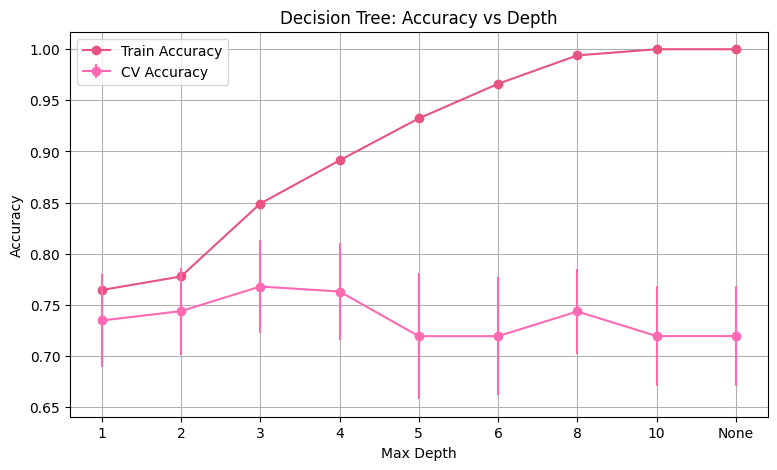

In [37]:
import matplotlib.pyplot as plt

x = range(len(depth_results))

plt.figure(figsize=(9, 5))

plt.plot(
    x,
    depth_results["Train Accuracy"],
    color="#E75480",
    marker="o",
    label="Train Accuracy"
)

plt.errorbar(
    x,
    depth_results["CV Accuracy"],
    yerr=depth_results["CV Std"],
    marker="o",
    color="hotpink",
    
    label="CV Accuracy"
)

plt.xticks(x, depth_results["Depth"])
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree: Accuracy vs Depth")
plt.legend()
plt.grid(True)

plt.show()

In [38]:
best_idx = depth_results["CV Accuracy"].idxmax()

best_cv = depth_results.loc[best_idx, "CV Accuracy"]
best_std = depth_results.loc[best_idx, "CV Std"]

limit = best_cv - best_std / np.sqrt(5)

candidates = depth_results[
    depth_results["CV Accuracy"] >= limit
]

chosen_depth = candidates.iloc[0]["Depth"]

print("Best CV Accuracy:", round(best_cv, 4))
print("1-SE Limit:", round(limit, 4))
print("Chosen Depth:", chosen_depth)

Best CV Accuracy: 0.7679
1-SE Limit: 0.7474
Chosen Depth: 3


In [39]:
leaf_sizes = [1, 2, 5, 10, 20, 40]

leaf_results = []

for leaf in leaf_sizes:
    model = DecisionTreeClassifier(
        criterion="entropy",
        max_depth=None,
        min_samples_leaf=leaf,
        random_state=SEED
    )

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy",
        return_train_score=True
    )

    model.fit(X_train, y_train)

    leaf_results.append({
        "Min Samples Leaf": leaf,
        "Leaves": model.get_n_leaves(),
        "Train Accuracy": scores["train_score"].mean(),
        "CV Accuracy": scores["test_score"].mean(),
        "CV Std": scores["test_score"].std()
    })

leaf_results = pd.DataFrame(leaf_results)

print(leaf_results.round(4))

   Min Samples Leaf  Leaves  Train Accuracy  CV Accuracy  CV Std
0                 1      35          1.0000       0.7195  0.0485
1                 2      32          0.9650       0.7195  0.0315
2                 5      22          0.8997       0.7437  0.0412
3                10      13          0.8514       0.8070  0.0395
4                20       7          0.7935       0.7434  0.0645
5                40       4          0.7645       0.7347  0.0457


Comparing Two Ways to Limit a Tree

max_depth limits how deep the tree can grow.

min_samples_leaf controls the minimum number of patients in each leaf.

Both methods can reduce overfitting. max_depth limits the number of levels, while min_samples_leaf prevents very small groups.

In [40]:
from sklearn.metrics import accuracy_score

final_tree = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=SEED
)

final_tree.fit(X_train, y_train)

test_pred = final_tree.predict(X_test)

test_accuracy = accuracy_score(y_test, test_pred)

n = len(y_test)
standard_error = np.sqrt(
    test_accuracy * (1 - test_accuracy) / n
)

print("Test Accuracy:", round(test_accuracy, 4))
print("Standard Error:", round(standard_error, 4))

Test Accuracy: 0.8
Standard Error: 0.0422


 Part 4 — Tree or Logistic Regression?

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

models = {
    "Chosen Tree": DecisionTreeClassifier(
        criterion="entropy",
        max_depth=3,
        random_state=SEED
    ),
    "Unlimited Tree": DecisionTreeClassifier(
        criterion="entropy",
        max_depth=None,
        random_state=SEED
    ),
    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000)
    )
}

results = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=("accuracy", "f1")
    )

    results.append({
        "Model": name,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Std": scores["test_accuracy"].std(),
        "CV F1": scores["test_f1"].mean()
    })

comparison = pd.DataFrame(results)

print(comparison.round(4))


                 Model  CV Accuracy  CV Std   CV F1
0          Chosen Tree       0.7679  0.0459  0.7414
1       Unlimited Tree       0.7195  0.0485  0.6964
2  Logistic Regression       0.8449  0.0509  0.8264


 Cross-Validation Comparison

| Model | CV Accuracy | CV Std | CV F1 |
|---|---|---|---|
| Chosen Tree | 0.7679 | 0.0459 | 0.7414 |
| Unlimited Tree | 0.7195 | 0.0485 | 0.6964 |
| Logistic Regression | 0.8449 | 0.0509 | 0.8264 |

Logistic Regression has the highest CV accuracy and F1 score.

The unlimited tree has the lowest accuracy. This suggests overfitting.

Logistic Regression looks better, but we also need to consider the variation between folds.

In [42]:
from sklearn.preprocessing import StandardScaler

tree1 = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=SEED
)

tree1.fit(X_train, y_train)
pred1 = tree1.predict(X_test)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

tree2 = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=SEED
)

tree2.fit(X_train_scaled, y_train)
pred2 = tree2.predict(X_test_scaled)

agreement = np.mean(pred1 == pred2)

print("Agreement:", agreement)

Agreement: 1.0


In [43]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

tree = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=SEED
)

logreg = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000)
)

tree.fit(X_train, y_train)
logreg.fit(X_train, y_train)

for name, model in [("Decision Tree", tree), ("Logistic Regression", logreg)]:
    pred = model.predict(X_test)

    print(name)
    print("Accuracy:", round(accuracy_score(y_test, pred), 4))
    print("F1:", round(f1_score(y_test, pred), 4))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, pred))
    print()

Decision Tree
Accuracy: 0.8
F1: 0.7857
Confusion Matrix:
[[39  9]
 [ 9 33]]

Logistic Regression
Accuracy: 0.8111
F1: 0.8046
Confusion Matrix:
[[38 10]
 [ 7 35]]



 Hold-out Results and Conclusion

| Model | Accuracy | F1 |
|---|---|---|
| Decision Tree | 0.8000 | 0.7857 |
| Logistic Regression | 0.8111 | 0.8046 |

**Decision Tree Confusion Matrix:**

[[39, 9], [9, 33]]

**Logistic Regression Confusion Matrix:**

[[38, 10], [7, 35]]

**Conclusion:**

I would choose Logistic Regression for this dataset because it has higher CV accuracy (0.8449 vs 0.7679) and a higher CV F1 score. On the test set, its accuracy is 0.8111 compared with 0.8000 for the tree. It also misses fewer patients with disease (7 vs 9). However, the test accuracy difference is small compared with the standard error of about 0.042, and the CV results also vary between folds. So I cannot be fully sure that Logistic Regression is better.

In [44]:
print("Scaling Agreement:", agreement)


Scaling Agreement: 1.0


Does a Tree Need Scaling?

I compared the decision tree before and after StandardScaler.

Agreement = 1

Decision trees usually do not need scaling because
scaling changes the values but keeps their order.